# Customer Intelligence / Country Segmentation Notebook

## Unsupervised Learning on Country Data

This notebook helps interns learn a full clustering workflow using the Kaggle dataset **Unsupervised Learning on Country Data**.

### Goals
- Load and inspect the data
- Clean and preprocess features
- Apply scaling
- Find the best number of clusters with K-Means
- Try DBSCAN as a second clustering method
- Visualize clusters with PCA
- Create simple country-level insights


## 1) Install required libraries

In [17]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

## 2) Import libraries

In [18]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

## 3) Load the dataset

Upload the CSV file from Kaggle when prompted.


In [19]:
from google.colab import files

uploaded = files.upload()

df = None
data_dict = None
for fname, content in uploaded.items():
    if 'dictionary' in fname.lower():
        data_dict = pd.read_csv(io.BytesIO(content))
    else:
        df = pd.read_csv(io.BytesIO(content))

display(data_dict)
df.head()

Saving Country-data.csv to Country-data (1).csv
Saving data-dictionary.csv to data-dictionary (1).csv


,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...
5,Income,Net income per person
6,Inflation,The measurement of the annual growth rate of t...
7,life_expec,The average number of years a new born child w...
8,total_fer,The number of children that would be born to e...
9,gdpp,The GDP per capita. Calculated as the Total GD...


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 4) Quick inspection

In [20]:
print('Shape:', df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


## 5) Expected columns

This dataset is commonly used for country clustering and usually contains:
- country
- child_mort
- exports
- health
- imports
- income
- inflation
- life_expec
- total_fer
- gdpp


In [21]:
print('Columns:', df.columns.tolist())

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## 6) Basic cleaning

Handle missing values, remove duplicates, and make sure numeric columns are clean.

In [22]:
df = df.copy()
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates()

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = [c for c in df.columns if c != 'country']
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df.isna().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


### 6b) Adjust columns using Data Dictionary insight

In [23]:
df['exports'] = (df['exports'] * df['gdpp']) / 100
df['health'] = (df['health'] * df['gdpp']) / 100
df['imports'] = (df['imports'] * df['gdpp']) / 100

df[['exports', 'health', 'imports', 'gdpp']].head()

,exports,health,imports,gdpp
0,55.30,41.9174,248.297,553
1,1145.20,267.8950,1987.740,4090
2,1712.64,185.9820,1400.440,4460
3,2199.19,100.6050,1514.370,3530
4,5551.00,735.6600,7185.800,12200


## 7) Exploratory Data Analysis

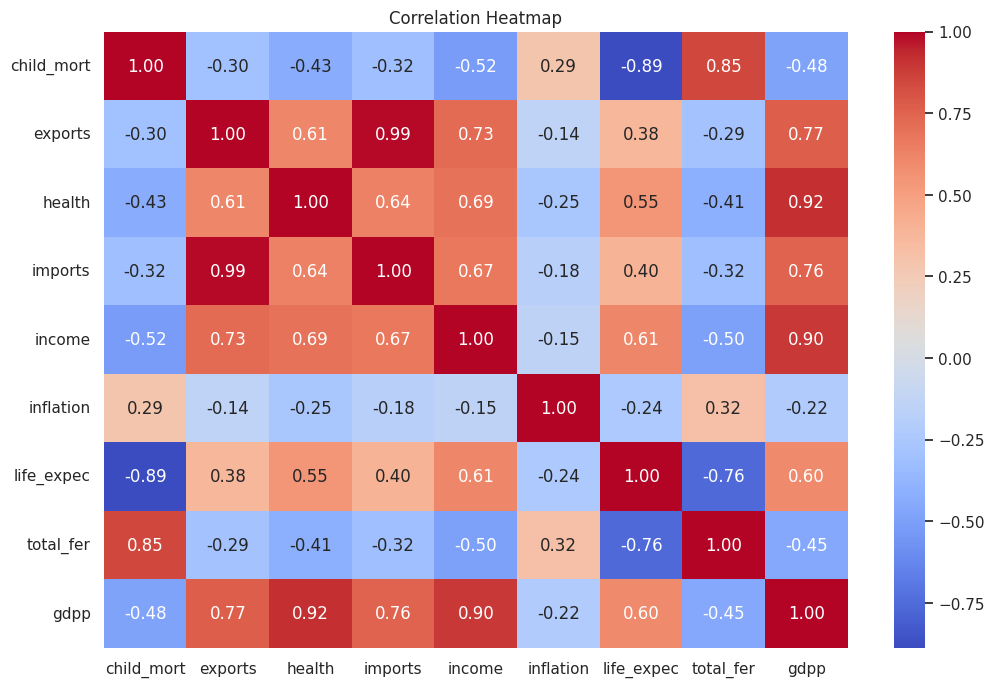

In [24]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

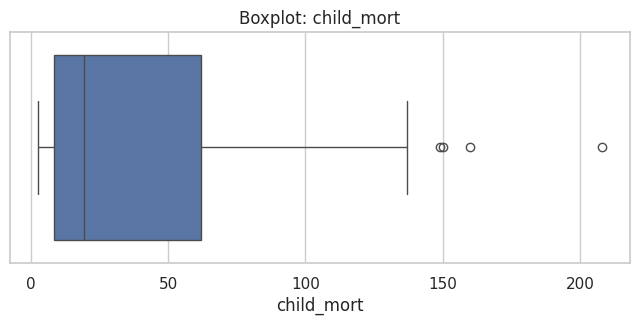

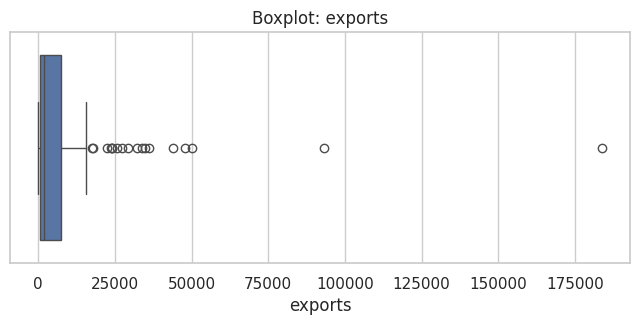

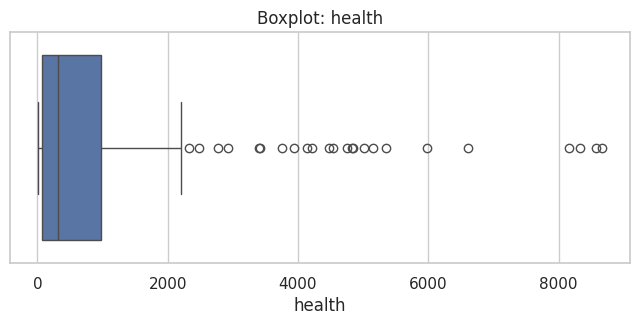

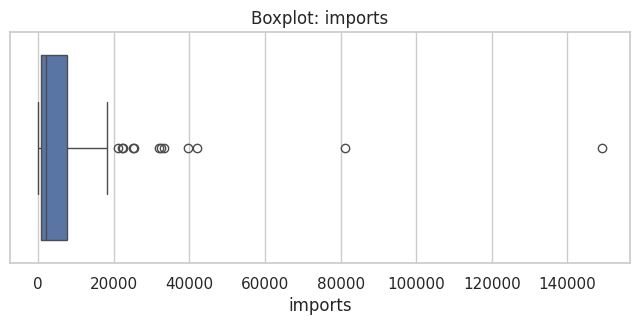

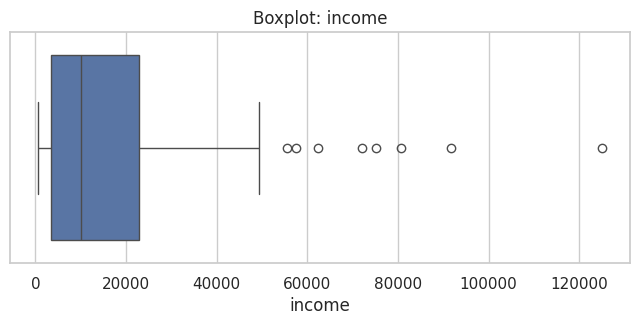

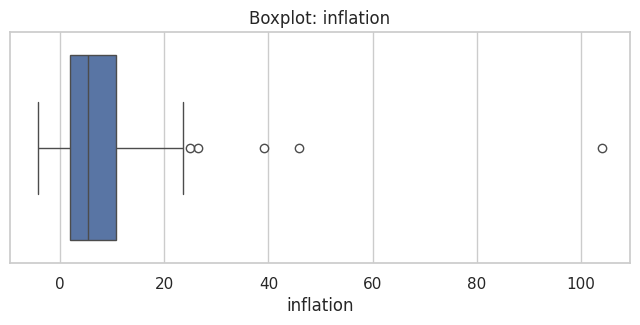

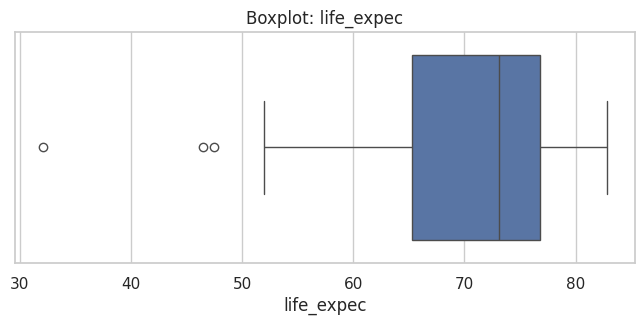

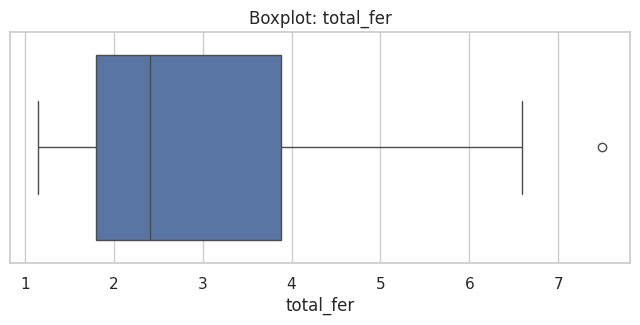

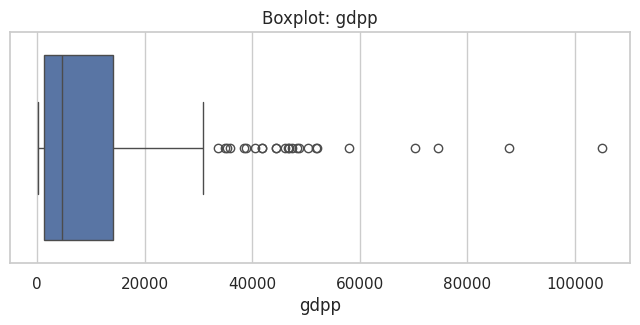

In [25]:
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

## 8) Feature scaling

Clustering works better when features are on the same scale.

In [26]:
features = df.drop(columns=['country'], errors='ignore')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled.shape

(167, 9)

## 9) K-Means: Elbow method

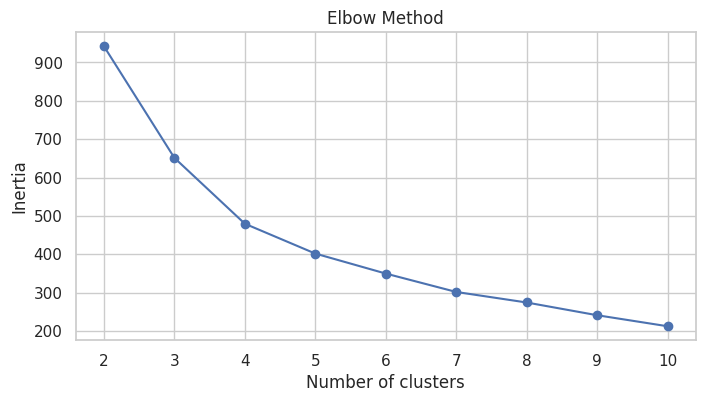

In [27]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

## 10) Train K-Means

In [28]:
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print('Silhouette Score:', silhouette_score(X_scaled, df['kmeans_cluster']))
df[['country', 'kmeans_cluster']].head()

Silhouette Score: 0.4218615812599681


,country,kmeans_cluster
0,Afghanistan,0
1,Albania,2
2,Algeria,2
3,Angola,0
4,Antigua and Barbuda,2


## 11) Try DBSCAN

In [29]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(df['dbscan_cluster'].value_counts().sort_index())

dbscan_cluster
-1     16
 0    151
Name: count, dtype: int64


## 12) PCA visualization

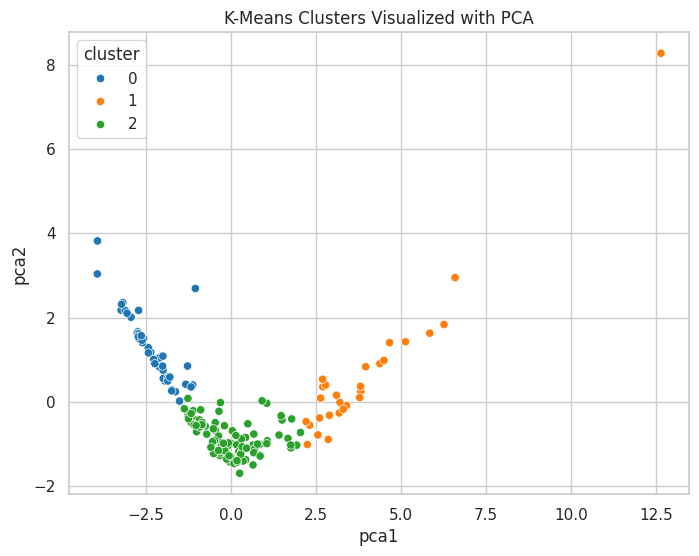

In [30]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

viz = pd.DataFrame({
    'pca1': X_pca[:, 0],
    'pca2': X_pca[:, 1],
    'cluster': df['kmeans_cluster']
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=viz, x='pca1', y='pca2', hue='cluster', palette='tab10')
plt.title('K-Means Clusters Visualized with PCA')
plt.show()

## 13) Cluster profiling

In [31]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,91.61,879.06,114.82,827.03,3897.35,11.91,59.24,4.99,1909.21
1,5.05,31038.24,4327.16,25818.10,50178.57,3.01,80.51,1.76,48114.29
2,20.36,3604.15,547.28,3710.45,13968.02,7.07,73.46,2.24,7979.91


### Classification + Ensemble Learning
This section fulfills the assignment's requirement to include classification
and ensemble learning (Random Forest, XGBoost) alongside clustering, using
the K-Means cluster label as the target variable.

Random Forest Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.86      1.00      0.92         6
           2       1.00      0.94      0.97        18

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.96        34
weighted avg       0.97      0.97      0.97        34

XGBoost Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00        18

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



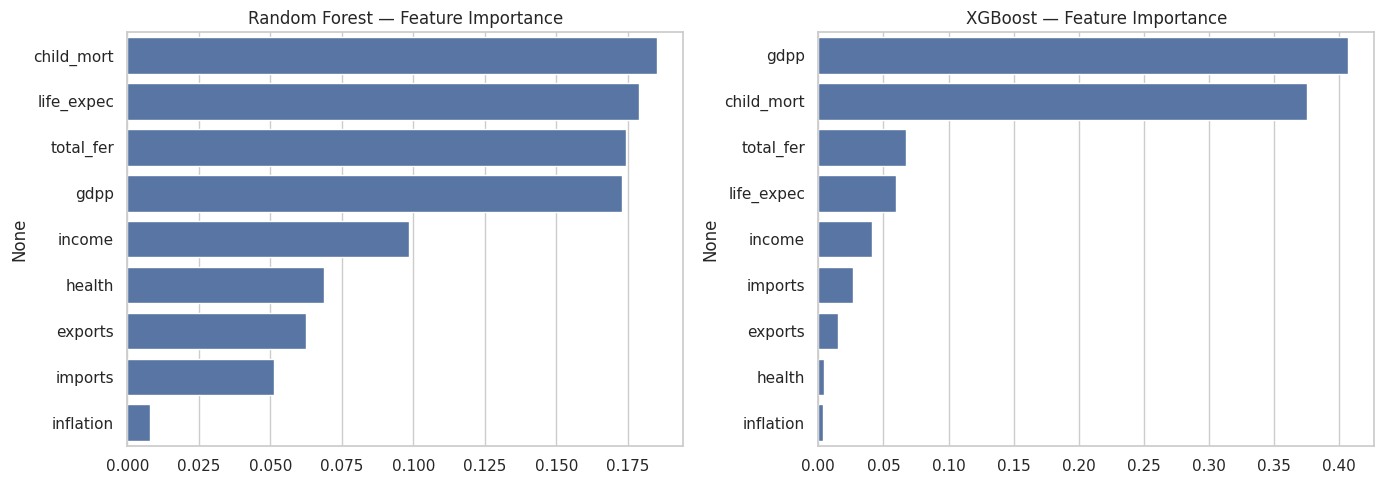

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

try:
    from xgboost import XGBClassifier
except ImportError:
    !pip install xgboost -q
    from xgboost import XGBClassifier

X = X_scaled
y = df['kmeans_cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

xgb = XGBClassifier(n_estimators=100, eval_metric='mlogloss', random_state=42)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_preds))
print(classification_report(y_test, xgb_preds))

importances_rf = pd.Series(rf.feature_importances_, index=numeric_cols).sort_values(ascending=False)
importances_xgb = pd.Series(xgb.feature_importances_, index=numeric_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=importances_rf.values, y=importances_rf.index, ax=axes[0])
axes[0].set_title("Random Forest — Feature Importance")
sns.barplot(x=importances_xgb.values, y=importances_xgb.index, ax=axes[1])
axes[1].set_title("XGBoost — Feature Importance")
plt.tight_layout()
plt.show()

## 14) Final Insights

**Q: Which cluster has high child mortality?**
Cluster 0 has by far the highest child mortality rate, averaging 91.6 deaths per
1000 live births — nearly 18x higher than Cluster 1 (5.0) and over 4x higher than
Cluster 2 (20.4). This cluster also has the lowest health spending (~115 per capita)
and lowest life expectancy of the three groups, confirming it represents countries
with the weakest healthcare infrastructure.

**Q: Which cluster has high income and gdpp?**
Cluster 1 clearly stands out with the highest income (~50,179 per capita) and
highest gdpp (well above the other two clusters). It also has the lowest child
mortality (5.0) and lowest inflation (3.01%), and the highest exports/imports/health
spending in absolute terms — all consistent with wealthy, economically developed
nations with strong trade and healthcare systems.

**Q: Which cluster looks underdeveloped?**
Cluster 0 looks the most underdeveloped — it combines the highest child mortality
(91.6), lowest income (~3,897), lowest gdpp, and highest inflation (11.91%) of the
three clusters. High inflation alongside low income suggests economic instability
on top of weak health and development indicators.

**Q: Which countries should be prioritized for aid?**
Countries in Cluster 0 should be prioritized for aid. This cluster shows the
combination most indicative of need: very high child mortality, very low income
and gdpp, low health spending, and high inflation — all pointing to limited
resources for basic healthcare and economic stability. Cluster 2 (moderate
values across all metrics) represents developing countries that are stable but
not yet high-income, and could be considered secondary priority, while Cluster 1
needs no aid.

**Additional observations:**
- DBSCAN (eps=1.5, min_samples=5) grouped 151 countries into a single dense
  cluster and flagged 16 as noise/outliers, rather than finding 3 distinct
  groups. This suggests the country data doesn't have strongly separated,
  density-based clusters at this eps value — K-Means's centroid-based approach
  gave a much clearer and more interpretable 3-way segmentation for this dataset.
- The Random Forest classifier achieved 97% accuracy predicting a country's
  K-Means cluster from its socio-economic features, confirming the three
  clusters are well-separated and consistently distinguishable based on
  child_mort, income, and gdpp — the features that also showed the highest
  importance in the model.